In [ ]:
import pandas as pd
DS = pd.read_csv(r"C:\Users\rishi\OneDrive\Desktop\Matplotlib & Seaborn\IPL_Dataset\IPL.csv")
DS

/tmp/ipykernel_724/695326671.py:2: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  DS = pd.read_csv("IPL_Dataset.zip")


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283673,283673,1529267,2026-04-16,T20,Indian Premier League,2,Punjab Kings,Mumbai Indians,16,1,...,96,3,NaN,NaN,2,2,0,"('MP Stoinis', 'P Simran Singh')",NaN,False
283674,283674,1529267,2026-04-16,T20,Indian Premier League,2,Punjab Kings,Mumbai Indians,16,1,...,97,3,NaN,NaN,2,3,0,"('MP Stoinis', 'P Simran Singh')",NaN,False
283675,283675,1529267,2026-04-16,T20,Indian Premier League,2,Punjab Kings,Mumbai Indians,16,2,...,98,3,NaN,NaN,6,4,0,"('MP Stoinis', 'P Simran Singh')",NaN,False
283676,283676,1529267,2026-04-16,T20,Indian Premier League,2,Punjab Kings,Mumbai Indians,16,3,...,98,3,NaN,NaN,6,4,0,"('MP Stoinis', 'P Simran Singh')",NaN,False


In [ ]:
import matplotlib.pyplot as plt

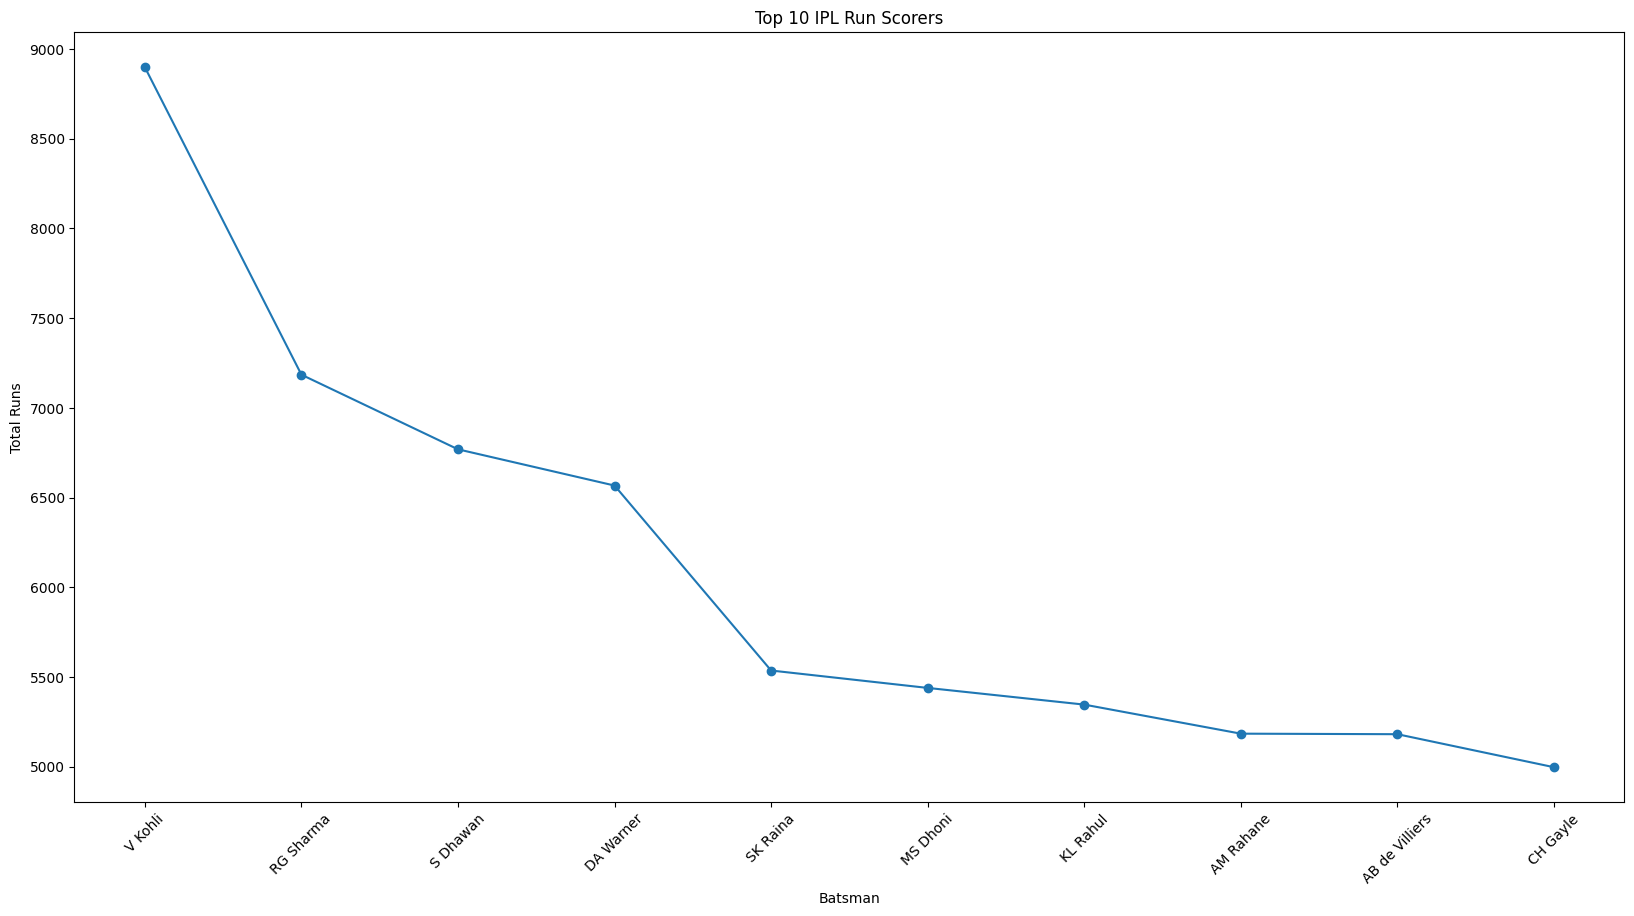

In [ ]:
#Single line plotting
batsman_runs = DS.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(20,10))
plt.plot(batsman_runs.index, batsman_runs.values, marker='o')
plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()

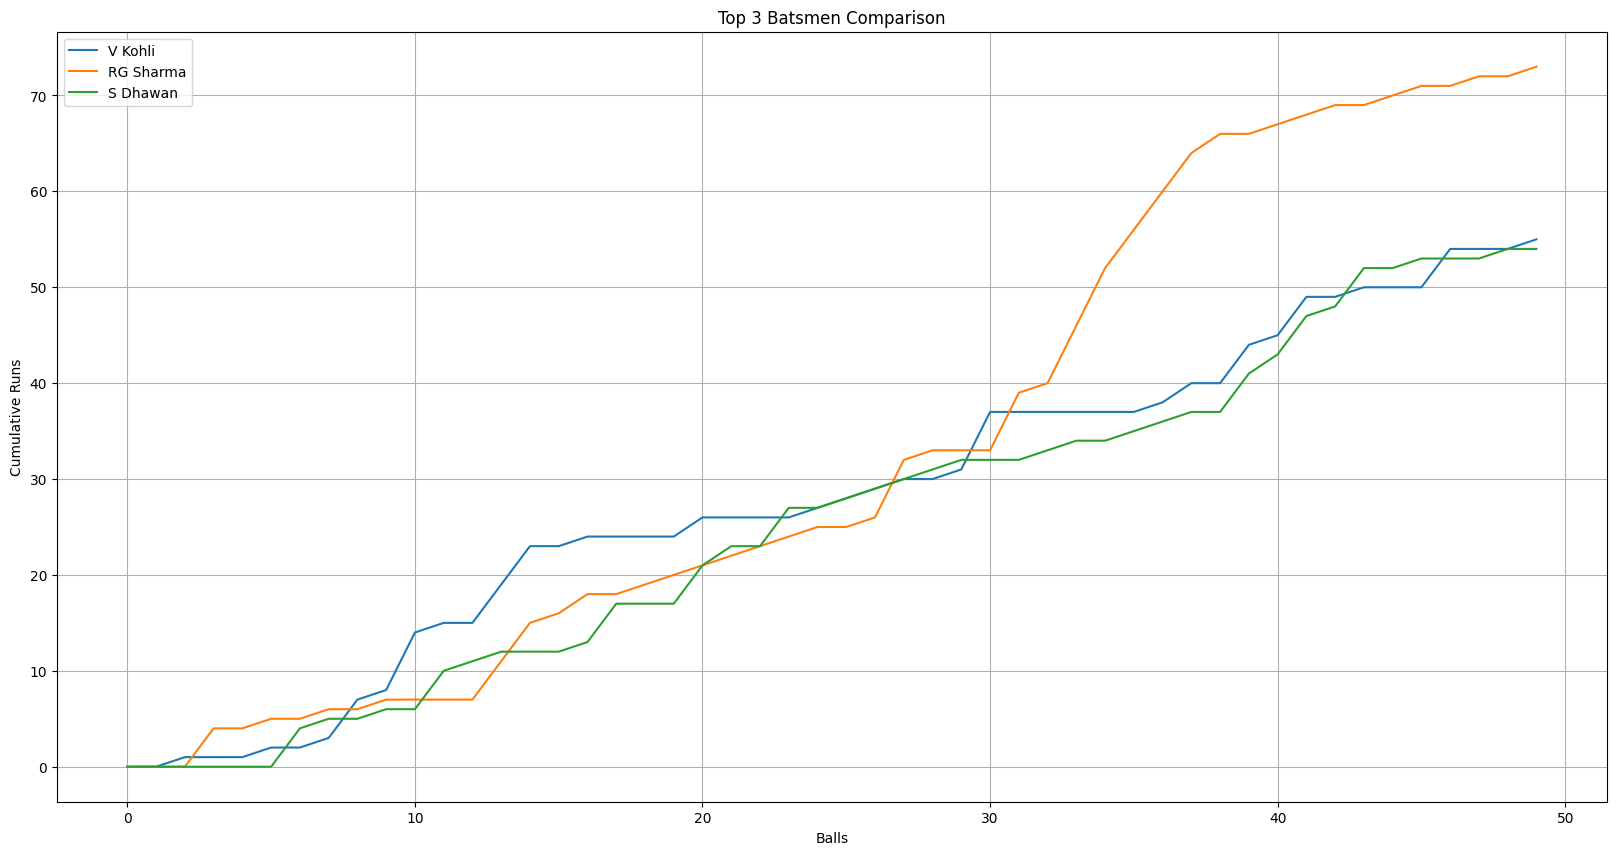

In [ ]:
#Multiple line plotting
top3 = DS.groupby('batter')['runs_batter'].sum().nlargest(3).index
comparison = {}

for player in top3:
    comparison[player] = DS[DS['batter'] == player]['runs_batter'].head(50).cumsum().values

comparison_df = pd.DataFrame(comparison)
comparison_df.plot(figsize=(20,10))

plt.title("Top 3 Batsmen Comparison")
plt.xlabel("Balls")
plt.ylabel("Cumulative Runs")
plt.grid(True)
plt.show()

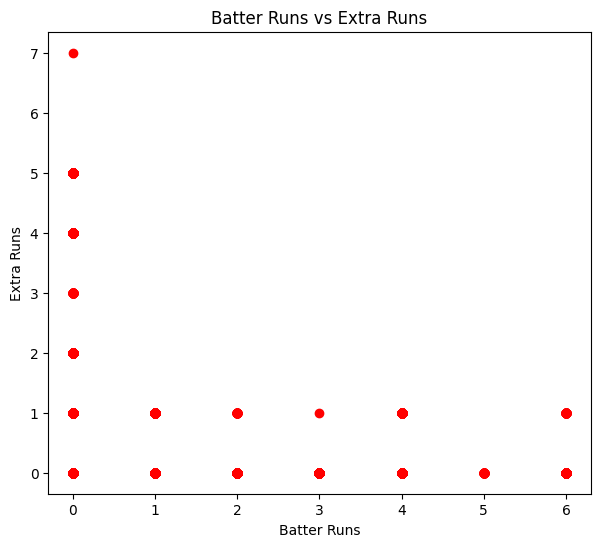

In [ ]:
#Scatter plotting
plt.figure(figsize=(7,6))
plt.scatter(DS['runs_batter'], DS['runs_extras'], color='red')

plt.title("Batter Runs vs Extra Runs")
plt.xlabel("Batter Runs")
plt.ylabel("Extra Runs")
plt.show()

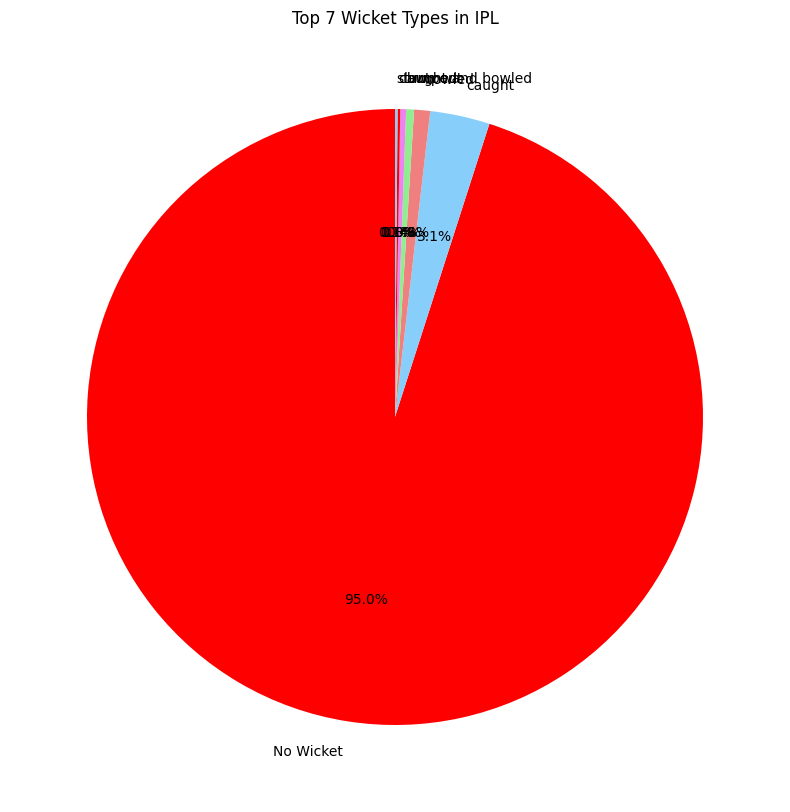

In [ ]:
from matplotlib import text
#Pie chart
DS['wicket_kind'] = DS['wicket_kind'].fillna('No Wicket')

wickets = DS['wicket_kind'].value_counts().head(7)

colors = ['red', 'lightskyblue', 'lightcoral', 'lightgreen', 'violet']
plt.figure(figsize=(20,10))
plt.pie(
    wickets,
    labels=wickets.index,
    colors=colors,
    autopct='%1.1f%%',
    textprops={'fontsize': 10},
    startangle=90
)

plt.title("Top 7 Wicket Types in IPL")
plt.show()

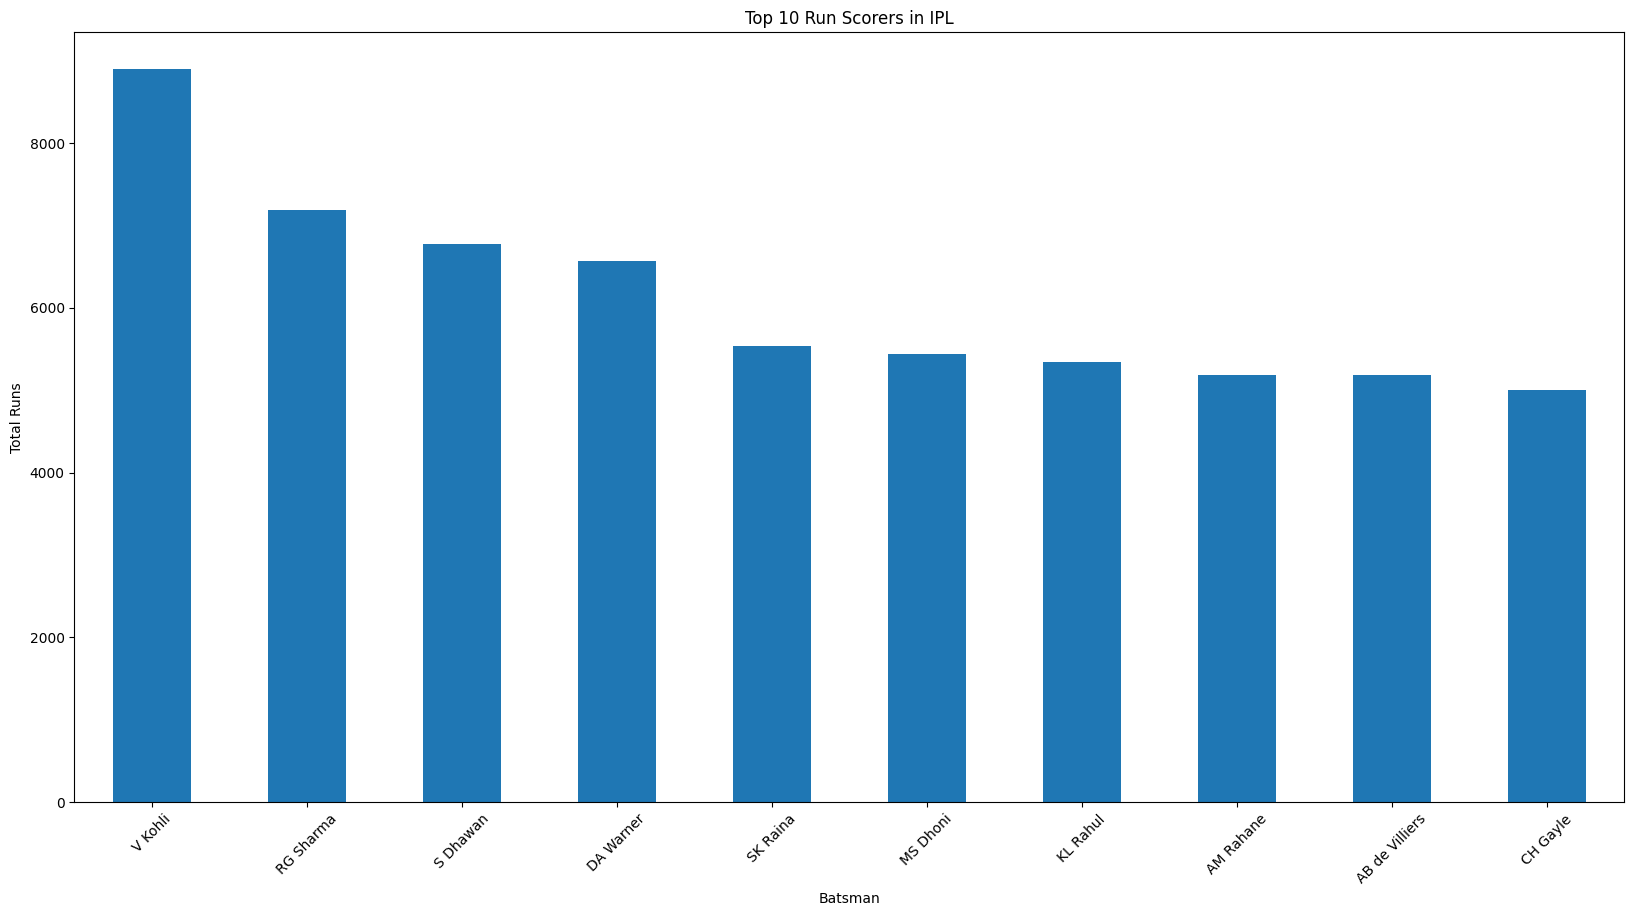

In [ ]:
#Bar chart
top_batsmen = DS.groupby('batter') ['runs_batter'].sum().sort_values(ascending=False).head(10)
top_batsmen
plt.figure(figsize=(20,10))
top_batsmen.plot(kind='bar')

plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
DS = pd.read_csv("IPL_Dataset.zip")

/tmp/ipykernel_1638/3818160029.py:2: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  DS = pd.read_csv("IPL_Dataset.zip")


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

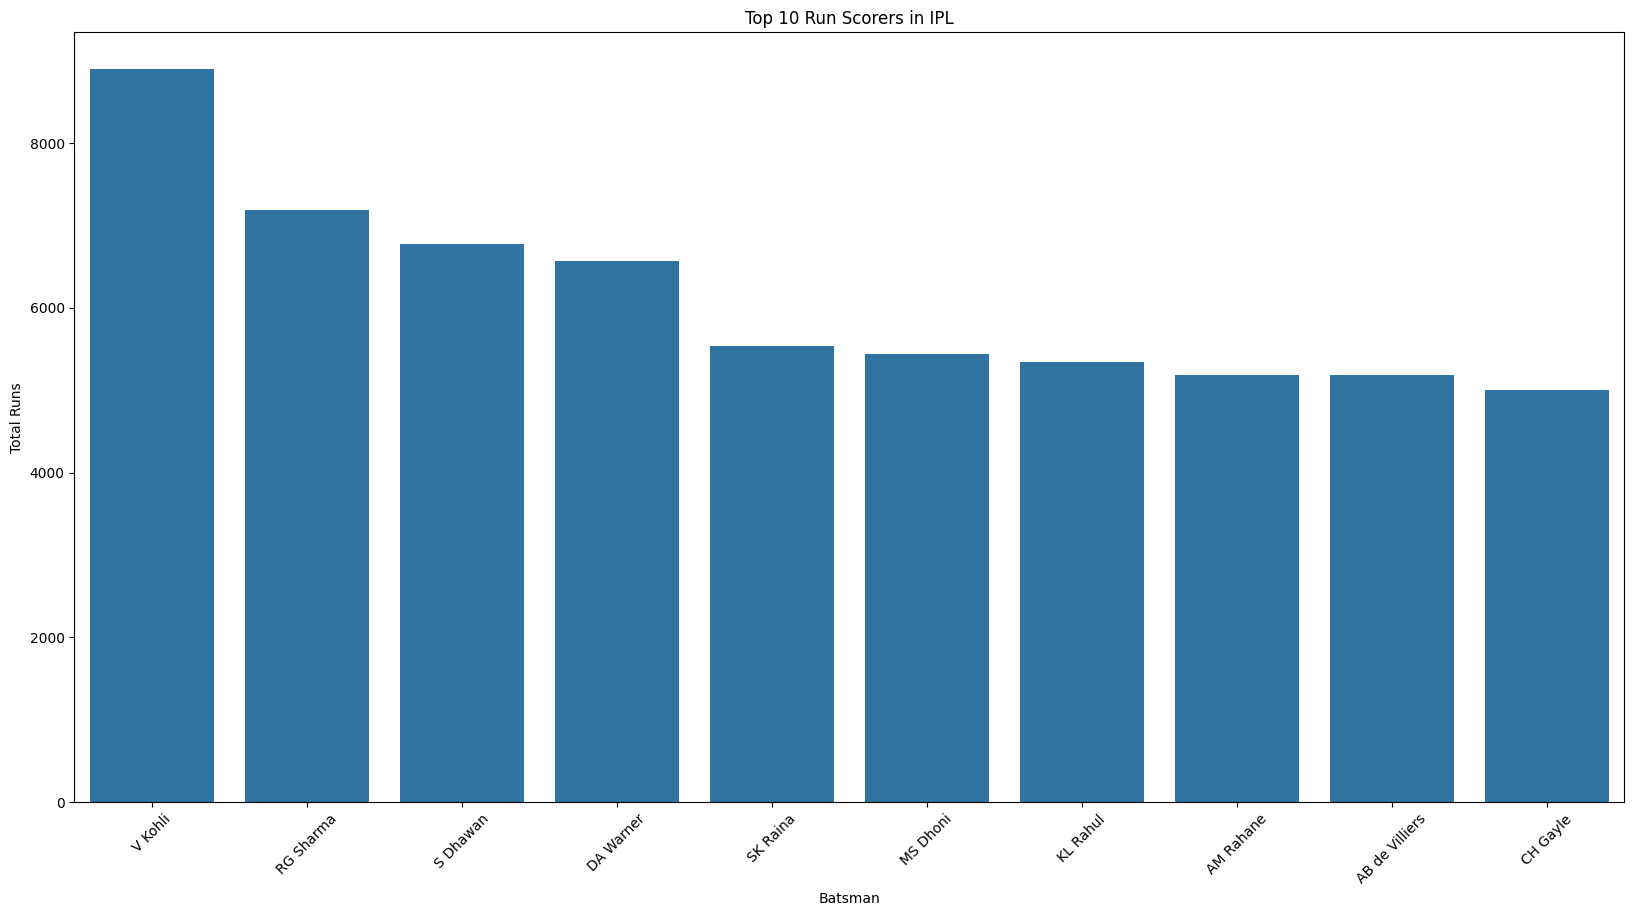

In [ ]:
top_batsmen = DS.groupby ('batter') ['runs_batter'].sum().sort_values (ascending=False).head (10)
plt.figure (figsize=(20,10))
sns.barplot (x=top_batsmen.index, y=top_batsmen.values)

plt.title ("Top 10 Run Scorers in IPL")
plt.xlabel ("Batsman")
plt.ylabel ("Total Runs")
plt.xticks (rotation=45)
plt.show ()

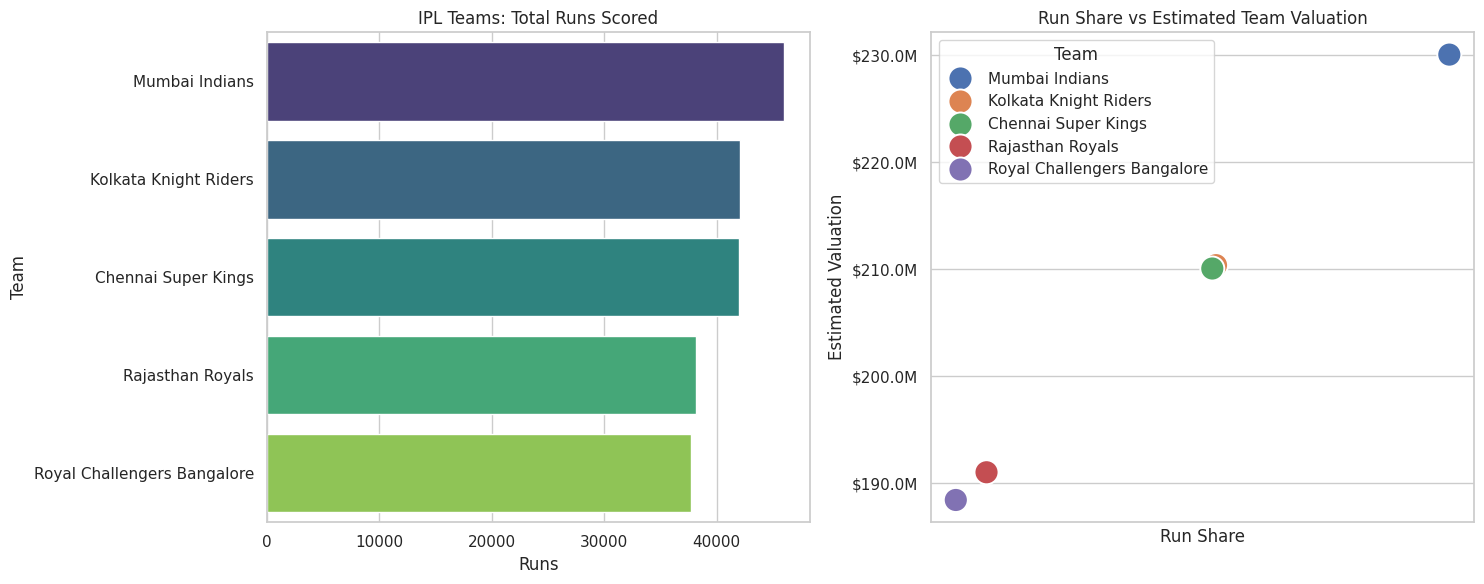

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from mizani.breaks import breaks_extended

DS = pd.read_csv("IPL_Dataset.zip", low_memory=False)
team_stats = (
    DS.groupby("batting_team")
      .agg(
          Total_Runs_Scored=("runs_total", "sum"),
          Total_Balls=("ball", "count")
      )
      .reset_index()
)

team_stats["Win_Percentage"] = (
    team_stats["Total_Runs_Scored"] /
    team_stats["Total_Runs_Scored"].sum()
)

team_stats["Estimated_Valuation_USD"] = (
    team_stats["Total_Runs_Scored"] * 5000
)

team_stats.rename(columns={"batting_team": "Team"}, inplace=True)
team_stats = team_stats.sort_values(
    by="Total_Runs_Scored",
    ascending=False
).head(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.set_theme(style="whitegrid")
sns.barplot(
    data=team_stats,
    x="Total_Runs_Scored",
    y="Team",
    hue="Team",
    palette="viridis",
    ax=ax1
)

ax1.set_title("IPL Teams: Total Runs Scored")
ax1.set_xlabel("Runs")
ax1.xaxis.set_major_locator
ax2.xaxis.set_major_formatter (mtick.PercentFormatter(1.0))

sns.scatterplot(
    data=team_stats,
    x="Win_Percentage",
    y="Estimated_Valuation_USD",
    hue="Team",
    s=300,
    palette="deep",
    ax=ax2
)

ax2.set_title("Run Share vs Estimated Team Valuation")
win_breaks = [0.40, 0.45, 0.50, 0.55, 0.60]

ax2.xaxis.set_major_locator(
    plt.FixedLocator(win_breaks)
)

ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'${x/1e6:.1f}M'
    )
)

ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(
        lambda x, pos: f'${x/1e6:.1f}M'
    )
)

ax2.set_xlabel("Run Share")
ax2.set_ylabel("Estimated Valuation")
plt.tight_layout()
plt.show()

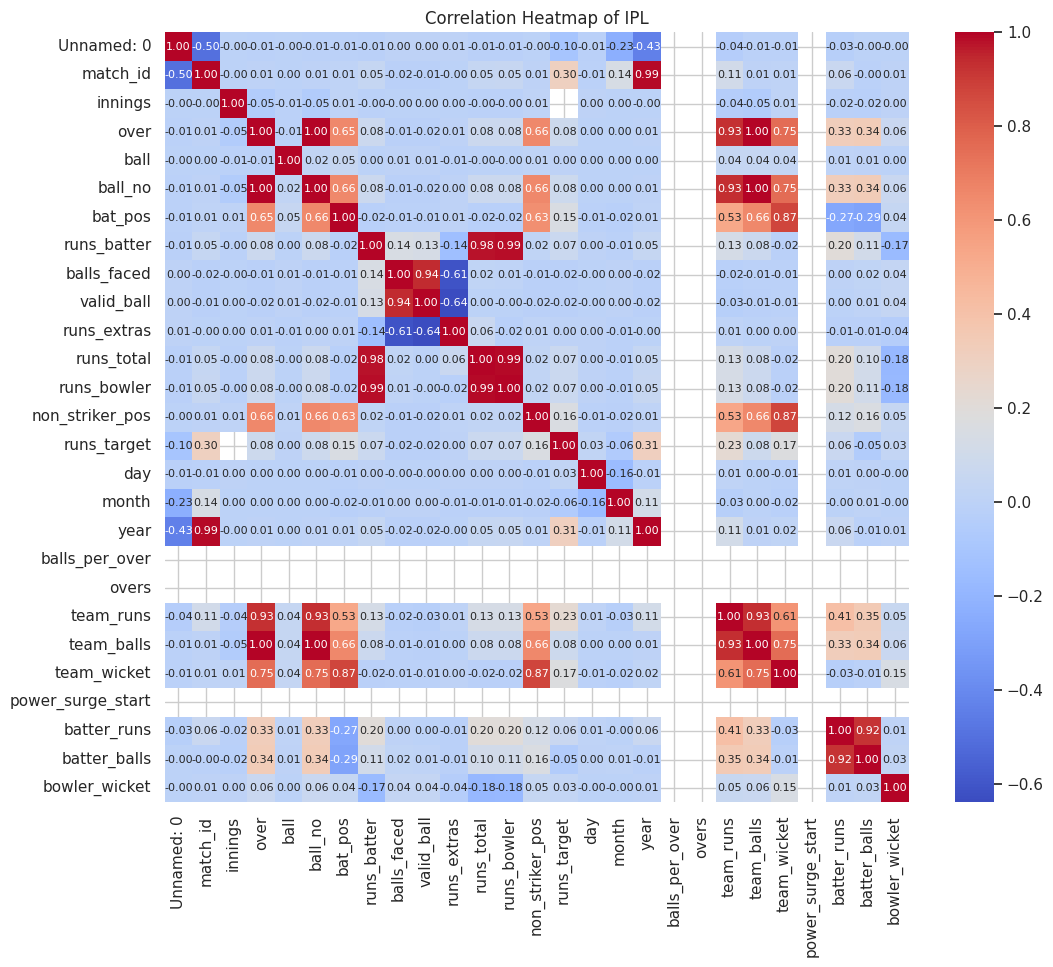

Unnamed: 0           int64
match_id             int64
date                object
match_type          object
event_name          object
                     ...  
batter_balls         int64
bowler_wicket        int64
batting_partners    object
next_batter         object
striker_out           bool
Length: 65, dtype: object
['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'o

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_data = DS.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap of IPL")
plt.show()
print(DS.dtypes)
print(DS.columns.tolist())



/tmp/ipykernel_2797/3871252784.py:4: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  DS = pd.read_csv("IPL_Dataset.zip")


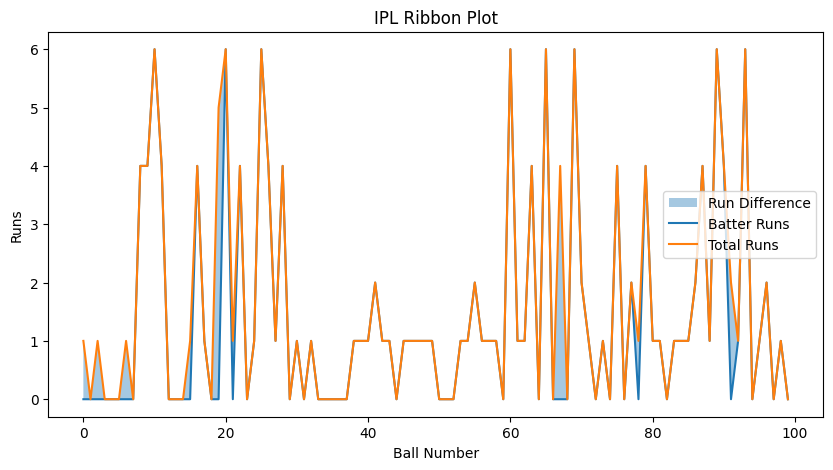

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

DS = pd.read_csv("IPL_Dataset.zip")
data = DS.head(100)
x = range(len(data))
plt.figure(figsize=(10,5))
plt.fill_between(
    x,
    data['runs_batter'],
    data['runs_total'],
    alpha=0.4,
    label='Run Difference'
)

plt.plot(x, data['runs_batter'], label='Batter Runs')
plt.plot(x, data['runs_total'], label='Total Runs')
plt.title("IPL Ribbon Plot")
plt.xlabel("Ball Number")
plt.ylabel("Runs")
plt.legend()
plt.show()